In [ ]:
import requests, os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Carga las variables del archivo .env
load_dotenv()
API_KEY = os.getenv("OPENTOPO_API_KEY")

if not API_KEY:
    raise ValueError(
        "No se encontró OPENTOPO_API_KEY en .env."
    )

# Bounding box ZMG con margen de 5km en cada lado
BBOX = {
    "south": 20.30,
    "north": 21.10,
    "west": -104.10,
    "east": -103.00
}

url = (
    f"https://portal.opentopography.org/API/globaldem"
    f"?demtype=SRTMGL1"
    f"&south={BBOX['south']}&north={BBOX['north']}"
    f"&west={BBOX['west']}&east={BBOX['east']}"
    f"&outputFormat=GTiff"
    f"&API_Key={API_KEY}"
)

output_path = "../data/raw/DEM_ZMG_SRTM30m.tif"

print("Descargando DEM...")
response = requests.get(url, stream=True, timeout=120)
response.raise_for_status()

with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Descarga completa: {os.path.getsize(output_path)/1e6:.1f} MB")

with rasterio.open(output_path) as src:
    print(f"CRS: {src.crs}")
    print(f"Shape: {src.shape}")
    dem_arr = src.read(1).astype(float)
    dem_arr[dem_arr == src.nodata] = np.nan
    print(f"Elev min: {np.nanmin(dem_arr):.0f} m")
    print(f"Elev max: {np.nanmax(dem_arr):.0f} m")

Descargando DEM...
Descarga completa: 12.4 MB
CRS     : EPSG:4326
Shape   : (2880, 3960)
Elev min: 469 m
Elev max: 2966 m


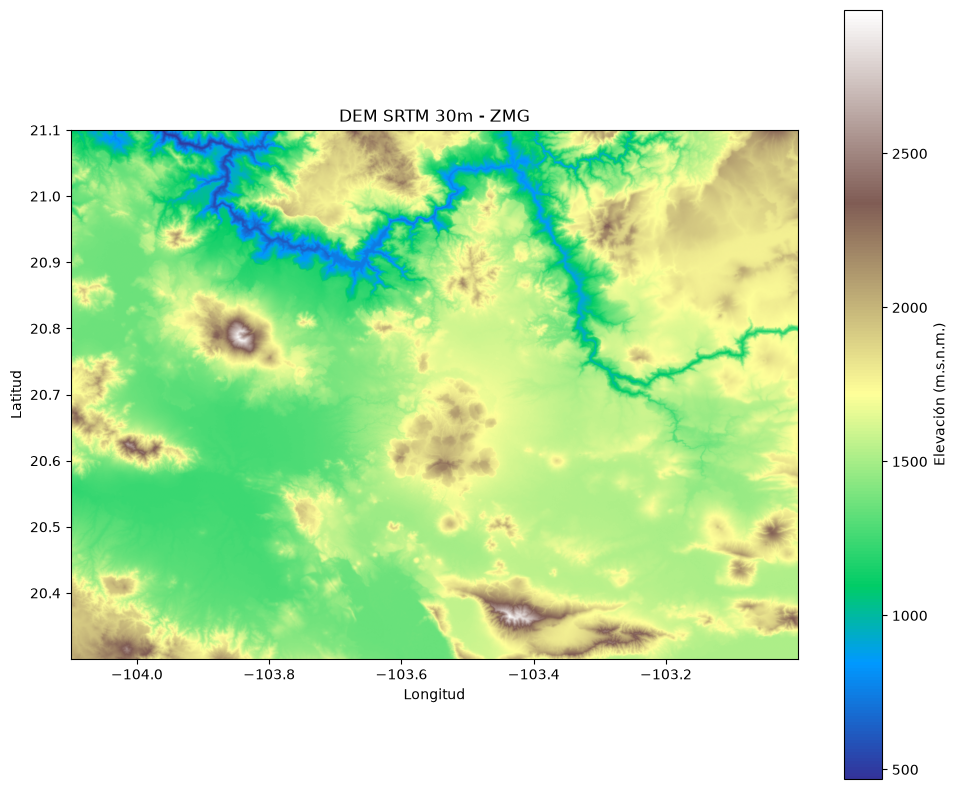

In [ ]:
# Visualización del DEM
with rasterio.open(output_path) as src:
    dem_arr = src.read(1).astype(float)
    dem_arr[dem_arr == src.nodata] = np.nan
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(dem_arr, cmap='terrain', extent=extent)
plt.colorbar(img, ax=ax, label='Elevación (m.s.n.m.)')
ax.set_title("DEM SRTM 30m - ZMG")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.savefig("../data/processed/DEM_preview.png", dpi=150)
plt.show()

In [4]:
# Pipeline con pysheds
from pysheds.grid import Grid

grid = Grid.from_raster(output_path)
dem = grid.read_raster(output_path)

print("Paso 1/5: Llenando depresiones...")
pit_filled = grid.fill_pits(dem)

print("Paso 2/5: Rellenando sumideros...")
flooded = grid.fill_depressions(pit_filled)

print("Paso 3/5: Resolviendo zonas planas...")
inflated = grid.resolve_flats(flooded)

print("Paso 4/5: Calculando dirección de flujo...")
fdir = grid.flowdir(inflated)

print("Paso 5/5: Calculando acumulación de flujo...")
acc = grid.accumulation(fdir)

print("\nPipeline completado.")
print(f"Acumulación máxima: {np.array(acc).max():,.0f} celdas")

Paso 1/5: Llenando depresiones...
Paso 2/5: Rellenando sumideros...
Paso 3/5: Resolviendo zonas planas...
Paso 4/5: Calculando dirección de flujo...
Paso 5/5: Calculando acumulación de flujo...

Pipeline completado.
Acumulación máxima: 6,399,778 celdas


In [ ]:
# Cálculo de TWI y pendiente
dem_array = np.array(flooded).astype(float)
acc_array = np.array(acc).astype(float)

# Resolución espacial en metros (SRTM aprox. 30m en latitud aprox. 20°)
res_m = 30.0

# Pendiente en radianes
dy, dx = np.gradient(dem_array, res_m, res_m)
slope = np.arctan(np.sqrt(dx**2 + dy**2))
slope = np.where(slope < 0.001, 0.001, slope)  # evitar división por cero

# Topographic Wetness Index
twi = np.log((acc_array + 1) / np.tan(slope))

print("TWI calculado:")
print(f"Mínimo: {np.nanmin(twi):.2f}")
print(f"Máximo: {np.nanmax(twi):.2f}")
print(f"Mediana: {np.nanmedian(twi):.2f}")

# Guardar TWI como raster
twi_path = "../data/processed/TWI_ZMG.tif"
with rasterio.open(output_path) as src:
    meta = src.meta.copy()
    meta.update(dtype='float32', count=1)
    with rasterio.open(twi_path, 'w', **meta) as dst:
        dst.write(twi.astype('float32'), 1)

print(f"\nTWI guardado en: {twi_path}")

TWI calculado:
  Mínimo : -0.94
  Máximo : 22.58
  Mediana: 3.75

TWI guardado en: ../data/processed/TWI_ZMG.tif


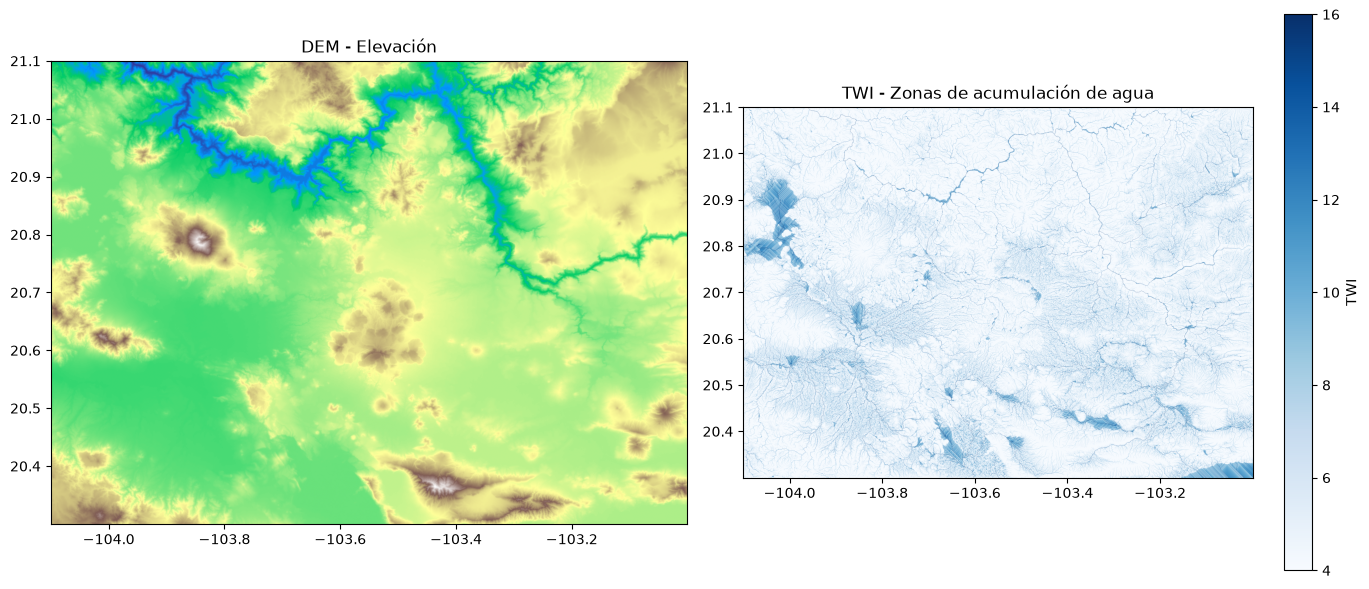

In [7]:
# Visualizar TWI en la ZMG
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(dem_array, cmap='terrain', extent=extent)
axes[0].set_title("DEM - Elevación")

im = axes[1].imshow(twi, cmap='Blues', extent=extent, vmin=4, vmax=16)
plt.colorbar(im, ax=axes[1], label='TWI')
axes[1].set_title("TWI - Zonas de acumulación de agua")

plt.tight_layout()
plt.savefig("../data/processed/DEM_TWI_comparativa.png", dpi=150)
plt.show()